# Customer Churn Prediction (Beginner Version)

A simple, beginner-friendly walkthrough of a churn-prediction workflow using a small,
hand-made 20-row dataset. This notebook follows the classic learn-the-workflow approach:
Logistic Regression, one clean dataset, step by step.

> **Note:** With only 20 rows, accuracy numbers here are for learning the workflow, not for
> judging a real model. See the `Customer-Churn-Prediction` (full) project for the same
> workflow applied to the real 7,043-row IBM Telco Customer Churn dataset, with a
> Logistic Regression vs. Random Forest comparison and hyperparameter tuning.


## Step 1 — Import libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report


## Step 2 — Load the dataset

In [2]:
df = pd.read_csv("dataset/customer_churn.csv")
df.head()


,CustomerID,Age,Tenure,MonthlyCharges,Contract,InternetService,SupportCalls,TotalCharges,Churn
0,1001,25,2,70,Month-to-month,Fiber optic,5,140,Yes
1,1002,45,24,50,One year,DSL,1,1200,No
2,1003,32,5,80,Month-to-month,Fiber optic,4,400,Yes
3,1004,52,36,45,Two year,DSL,0,1620,No
4,1005,28,3,75,Month-to-month,Fiber optic,6,225,Yes


## Step 3 — Understand the dataset

In [3]:
df.shape


(20, 9)

In [4]:
df.columns


Index(['CustomerID', 'Age', 'Tenure', 'MonthlyCharges', 'Contract',
       'InternetService', 'SupportCalls', 'TotalCharges', 'Churn'],
      dtype='str')

In [5]:
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 20 entries, 0 to 19
Data columns (total 9 columns):
 #   Column           Non-Null Count  Dtype
---  ------           --------------  -----
 0   CustomerID       20 non-null     int64
 1   Age              20 non-null     int64
 2   Tenure           20 non-null     int64
 3   MonthlyCharges   20 non-null     int64
 4   Contract         20 non-null     str  
 5   InternetService  20 non-null     str  
 6   SupportCalls     20 non-null     int64
 7   TotalCharges     20 non-null     int64
 8   Churn            20 non-null     str  
dtypes: int64(6), str(3)
memory usage: 1.5 KB


In [6]:
df.describe()


,CustomerID,Age,Tenure,MonthlyCharges,SupportCalls,TotalCharges
count,20.00000,20.000000,20.000000,20.00000,20.000000,20.000000
mean,1010.50000,40.500000,18.800000,64.70000,3.000000,973.850000
std,5.91608,11.408676,15.746679,17.46003,2.635786,652.559114
min,1001.00000,25.000000,1.000000,40.00000,0.000000,95.000000
25%,1005.75000,30.500000,4.750000,49.50000,0.750000,390.000000
50%,1010.50000,39.000000,15.000000,62.50000,2.500000,930.000000
75%,1015.25000,49.750000,31.500000,78.50000,5.000000,1627.500000
max,1020.00000,60.000000,48.000000,95.00000,8.000000,1920.000000


## Step 4 — Check for missing values

In [7]:
df.isnull().sum()


CustomerID         0
Age                0
Tenure             0
MonthlyCharges     0
Contract           0
InternetService    0
SupportCalls       0
TotalCharges       0
Churn              0
dtype: int64

## Step 5 — Analyze customer churn

In [8]:
print(df["Churn"].value_counts())


Churn
Yes    10
No     10
Name: count, dtype: int64


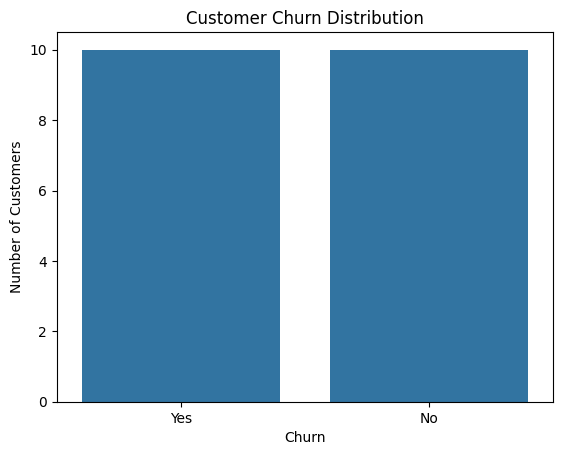

In [9]:
sns.countplot(x="Churn", data=df)

plt.title("Customer Churn Distribution")
plt.xlabel("Churn")
plt.ylabel("Number of Customers")

plt.show()


## Step 6 — Analyze churn by contract

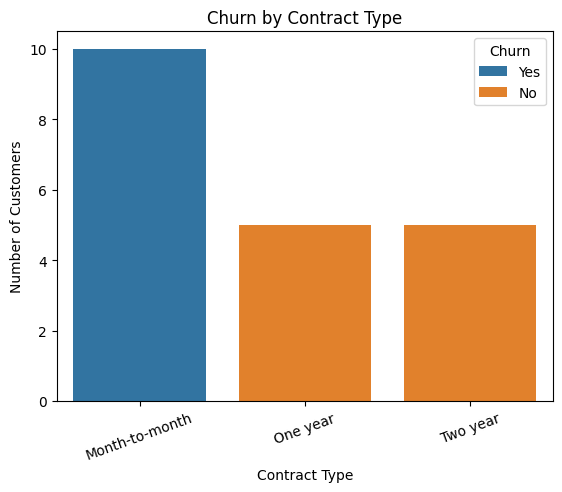

In [10]:
sns.countplot(x="Contract", hue="Churn", data=df)

plt.title("Churn by Contract Type")
plt.xlabel("Contract Type")
plt.ylabel("Number of Customers")

plt.xticks(rotation=20)

plt.show()


## Step 7 — Analyze monthly charges

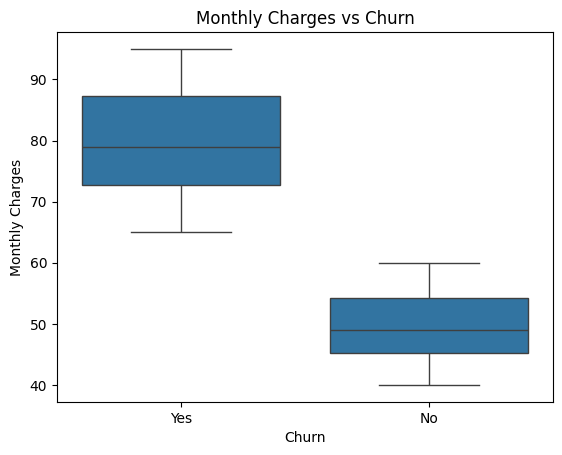

In [11]:
sns.boxplot(x="Churn", y="MonthlyCharges", data=df)

plt.title("Monthly Charges vs Churn")
plt.xlabel("Churn")
plt.ylabel("Monthly Charges")

plt.show()


## Step 8 — Analyze support calls

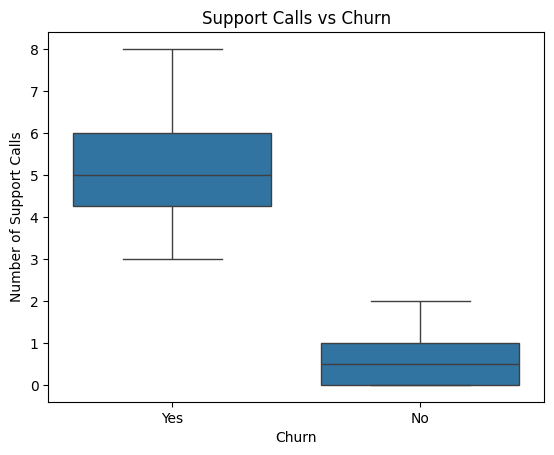

In [12]:
sns.boxplot(x="Churn", y="SupportCalls", data=df)

plt.title("Support Calls vs Churn")
plt.xlabel("Churn")
plt.ylabel("Number of Support Calls")

plt.show()


## Step 9 — Prepare the data for Machine Learning

Our model can't directly understand text like `Month-to-month`, `One year`, `Fiber optic`,
or `DSL` — so we convert categorical values into numbers.


In [13]:
data = df.copy()


In [14]:
label_encoder = LabelEncoder()

data["Contract"] = label_encoder.fit_transform(data["Contract"])
data["InternetService"] = label_encoder.fit_transform(data["InternetService"])
data["Churn"] = label_encoder.fit_transform(data["Churn"])

data.head()


,CustomerID,Age,Tenure,MonthlyCharges,Contract,InternetService,SupportCalls,TotalCharges,Churn
0,1001,25,2,70,0,1,5,140,1
1,1002,45,24,50,1,0,1,1200,0
2,1003,32,5,80,0,1,4,400,1
3,1004,52,36,45,2,0,0,1620,0
4,1005,28,3,75,0,1,6,225,1


## Step 10 — Select features

In [15]:
X = data.drop(["CustomerID", "Churn"], axis=1)
y = data["Churn"]

X.columns


Index(['Age', 'Tenure', 'MonthlyCharges', 'Contract', 'InternetService',
       'SupportCalls', 'TotalCharges'],
      dtype='str')

## Step 11 — Split the dataset

In [16]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Train size:", X_train.shape, " Test size:", X_test.shape)


Train size: (16, 7)  Test size: (4, 7)


## Step 12 — Create the Machine Learning model

In [17]:
model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)


,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

## Step 13 — Make predictions

In [18]:
y_pred = model.predict(X_test)
print(y_pred)


[0 0 1 1]


## Step 14 — Check accuracy

In [19]:
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)


Accuracy: 1.0


**Important:** because our dataset contains only 20 rows, this accuracy isn't meaningful
enough to judge a real-world model. We're using this small dataset to learn the complete
workflow. For a real project, use a larger dataset (see the full version of this project).


## Step 15 — Confusion matrix

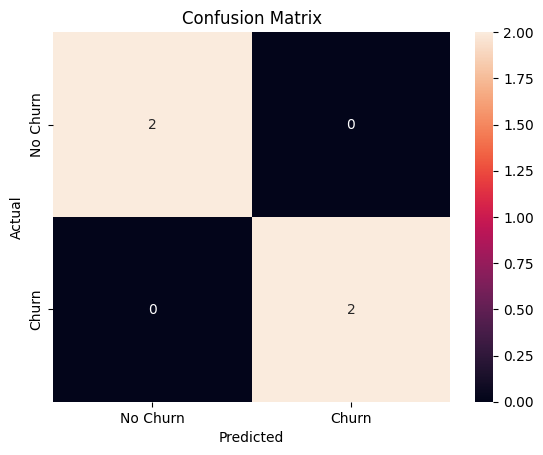

In [20]:
cm = confusion_matrix(y_test, y_pred)

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    xticklabels=["No Churn", "Churn"],
    yticklabels=["No Churn", "Churn"]
)

plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()


## Step 16 — Classification report

In [21]:
print(classification_report(y_test, y_pred))


              precision    recall  f1-score   support

           0       1.00      1.00      1.00         2
           1       1.00      1.00      1.00         2

    accuracy                           1.00         4
   macro avg       1.00      1.00      1.00         4
weighted avg       1.00      1.00      1.00         4



## Step 17 — Test the model with a new customer

In [22]:
new_customer = pd.DataFrame({
    "Age": [30],
    "Tenure": [3],
    "MonthlyCharges": [85],
    "Contract": [0],
    "InternetService": [1],
    "SupportCalls": [6],
    "TotalCharges": [255]
})

prediction = model.predict(new_customer)
print(prediction)


[1]


## Step 18 — Make the prediction user-friendly

In [23]:
if prediction[0] == 1:
    print("The customer is likely to churn.")
else:
    print("The customer is likely to stay.")


The customer is likely to churn.

## Step 19 — Train a Random Forest Classifier

Logistic Regression is a good baseline, but let's see if a Random Forest — an ensemble of
many decision trees — does better on this same data.


In [24]:
from sklearn.ensemble import RandomForestClassifier


### Create the model

In [25]:
rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)


### Train the model

In [26]:
rf_model.fit(X_train, y_train)


,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

### Make predictions

In [27]:
rf_pred = rf_model.predict(X_test)
print(rf_pred)


[0 0 1 1]


### Check accuracy

In [28]:
rf_accuracy = accuracy_score(y_test, rf_pred)

print("Random Forest Accuracy:", rf_accuracy)


Random Forest Accuracy: 1.0


### Confusion matrix

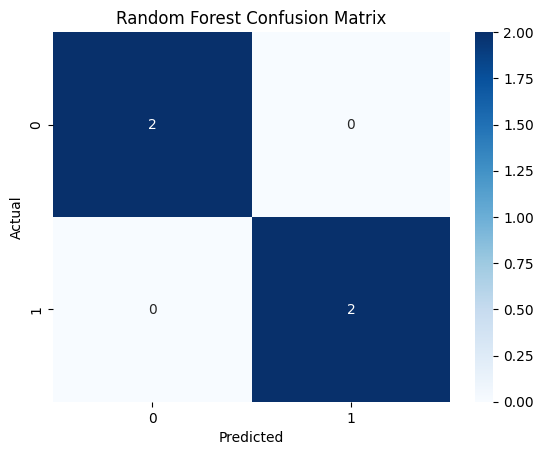

In [29]:
cm = confusion_matrix(y_test, rf_pred)

sns.heatmap(cm,
            annot=True,
            fmt='d',
            cmap='Blues')

plt.title("Random Forest Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()


### Classification report

In [30]:
print(classification_report(y_test, rf_pred))


              precision    recall  f1-score   support

           0       1.00      1.00      1.00         2
           1       1.00      1.00      1.00         2

    accuracy                           1.00         4
   macro avg       1.00      1.00      1.00         4
weighted avg       1.00      1.00      1.00         4



## Step 20 — Compare models

In [31]:
models = ['Logistic Regression', 'Random Forest']

accuracies = [
    accuracy_score(y_test, y_pred),
    accuracy_score(y_test, rf_pred)
]

comparison = pd.DataFrame({
    "Model": models,
    "Accuracy": accuracies
})

print(comparison)


                 Model  Accuracy
0  Logistic Regression       1.0
1        Random Forest       1.0


## Step 21 — Plot model accuracy

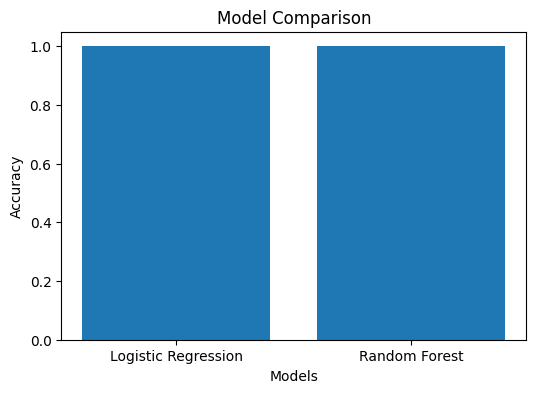

In [32]:
plt.figure(figsize=(6,4))

plt.bar(models, accuracies)

plt.title("Model Comparison")
plt.xlabel("Models")
plt.ylabel("Accuracy")

plt.show()


## Step 22 — Feature importance

In [33]:
importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": rf_model.feature_importances_
})

importance = importance.sort_values(
    by="Importance",
    ascending=False
)

print(importance)


           Feature  Importance
1           Tenure        0.18
0              Age        0.17
5     SupportCalls        0.17
2   MonthlyCharges        0.15
6     TotalCharges        0.15
4  InternetService        0.09
3         Contract        0.09


### Plot feature importance

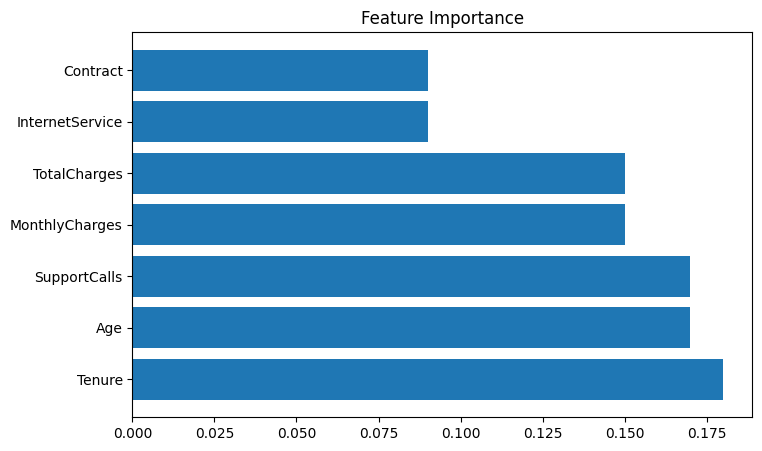

In [34]:
plt.figure(figsize=(8,5))

plt.barh(
    importance["Feature"],
    importance["Importance"]
)

plt.title("Feature Importance")

plt.show()


This tells which features contribute most to predicting customer churn.

## Step 23 — Save the model

Once trained, a model can be saved to disk with `joblib` so it can be reused later without
retraining. (If `joblib` isn't installed: `pip install joblib` — it's included in
`requirements.txt`.)


In [35]:
import joblib


In [36]:
joblib.dump(rf_model, "customer_churn_model.pkl")


['customer_churn_model.pkl']

## Step 24 — Load the saved model

In [37]:
loaded_model = joblib.load("customer_churn_model.pkl")


## Step 25 — Predict using the saved model

In [38]:
new_customer = pd.DataFrame({
    "Age":[30],
    "Tenure":[3],
    "MonthlyCharges":[90],
    "Contract":[0],
    "InternetService":[1],
    "SupportCalls":[5],
    "TotalCharges":[270]
})

prediction = loaded_model.predict(new_customer)

if prediction[0] == 1:
    print("Customer is likely to churn.")
else:
    print("Customer is likely to stay.")


Customer is likely to churn.


## Step 26 — Final conclusion

In [39]:
print("Project Completed Successfully!")

print("Best Model: Random Forest")

print("Customer Churn Prediction System Ready")


Project Completed Successfully!
Best Model: Random Forest
Customer Churn Prediction System Ready


## Project workflow

```
Customer Data
      ↓
Data Cleaning
      ↓
Exploratory Data Analysis
      ↓
Data Visualization
      ↓
Categorical Encoding
      ↓
Train/Test Split
      ↓
Logistic Regression  +  Random Forest
      ↓
Model Training
      ↓
Prediction
      ↓
Evaluation & Comparison
      ↓
Feature Importance
      ↓
Save / Load Model (joblib)
      ↓
Customer Churn Prediction System
```

This is the same shape of workflow used in the full-scale version of this project — just
scaled down to a tiny dataset so each step is easy to inspect by eye.
